# RL Post-Training — 0 : le reward model from scratch (Bradley-Terry)

**Série RL Post-Training** (`rlpt_*`) — cette série explore l'**alignement** de modèles de langage
sur un signal de préférence (RLHF, GRPO, DPO). Le pipeline complet d'InstructGPT comporte trois
étages : collecter des **comparaisons humaines**, en **entraîner un reward model**, puis optimiser
la politique contre ce reward model sous contrainte KL.

`rlpt_1` commence directement au troisième étage avec un reward model **jouet codé en dur**
(`rm(seq, prompt)` : `+1` si `a` en position 1 pour le prompt A, `e` en position 5 pour le prompt
B). Ce notebook est l'étage manquant, numéroté 0 parce qu'il le précède : **d'où vient le reward
quand personne ne peut l'écrire ?** Réponse : on l'apprend à partir de paires de préférences.

Le fil conducteur est le formalisme de **Bradley-Terry (1952)**, adaptré aux préférences par
Christiano et al. (2017) puis Ouyang et al. (2022) :

$$P(y_w \succ y_l \mid x) = \sigma\big(r_\theta(x, y_w) - r_\theta(x, y_l)\big)$$

où $y_w$ (winning) et $y_l$ (losing) sont deux réponses au même prompt $x$, $\sigma$ la sigmoïde
et $r_\theta$ un réseau à tête scalaire. L'entraînement maximise la vraisemblance des choix
observés — exactement une régression logistique sur les **différences** de reward.

**Prérequis** : PyTorch de base (`rl_6`), le concept de reward (`rl_1`, `rl_5`). Aucune
dépendance au-delà de `torch`/`numpy`/`matplotlib` : tout est from scratch, CPU, déterministe
(multi-seed `[0, 1, 7, 42]`, convention review C).

**Plan** : un monde synthétique avec un reward *vrai* connu (§2), un juge qui choisit entre deux
réponses selon Bradley-Terry (§3), un reward model entraîné par MLE (§4-6), et une évaluation
*honnête* — plafond de Bayes, calibration, identification affine (§7-10). Trois exercices closent
le notebook.

## 1. Le problème : noter est dur, comparer est facile

En RL classique, le reward est **donné** par l'environnement (gagner la partie, atteindre le but).
Pour aligner un modèle de langage, personne ne sait écrire $r(\text{« bonne réponse »})$. L'exploit
du RLHF (Christiano et al. 2017) est un déplacement : les humains ne savent pas **noter** une
réponse sur une échelle, mais savent très bien **comparer** deux réponses au même prompt.

Le contrat est donc :

| Ce qui existe | Ce qu'on veut |
|---|---|
| Des paires $(y_w, y_l)$ — « je préfère celle-ci à celle-là » | Une fonction $r_\theta(x, y)$ utilisable comme reward par PPO/GRPO (`rlpt_1`) |

Bradley-Terry transforme les préférences en probabilités : la paire impose seulement que
$r_\theta(x, y_w) > r_\theta(x, y_l)$, avec un écart proportionné à la fiabilité du juge. C'est
une hypothèse de **rationalité du juge** — on verra précisément ce qu'elle vaut dans le monde
synthétique, où le vrai reward est connu et donc mesurable.

**Pourquoi un monde synthétique ?** Sur des données réelles, on ne peut pas mesurer l'erreur du
reward model (personne ne connaît $r^*$). Ici, $r^*$ est connu par construction : on peut calculer
le **plafond de Bayes** (l'accuracy maximale atteignable, même avec $r^*$ parfait, parce que le
juge est stochastique), le plancher de Brier, et la corrélation $\hat r$ vs $r^*$. C'est la
différence entre *évaluer* un reward model et *prouver* qu'il est honnête.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
SEEDS = [0, 1, 7, 42]          # multi-seed (convention pr-review C)
LEN_R = 8                      # longueur de la reponse (comme rlpt_1)
TOK = ['<pA>', '<pB>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
V = {c: i for i, c in enumerate(TOK)}
DEV = 'cpu'

print(f"vocabulaire : {len(TOK)} tokens ({TOK[2:]} + prompts {TOK[:2]})")
print(f"reponse de {LEN_R} tokens, seeds {SEEDS}, device {DEV}")
print(torch.__version__)

vocabulaire : 10 tokens (['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'] + prompts ['<pA>', '<pB>'])
reponse de 8 tokens, seeds [0, 1, 7, 42], device cpu
2.13.0+cpu


## 2. Le monde synthétique : une oracle graduée

On reprend le monde de `rlpt_1` à l'identique — vocabulaire de 8 tokens de contenu `a`..`h`, deux
prompts `<pA>`/`<pB>`, réponses de 8 tokens — mais son oracle binaire (`0`/`1`) est remplacée par
une version **graduée**, prolongement naturel de la même structure :

- **poids par token** $w(t)$ : `a` porteur (+0.30), `e` porteur (+0.25), ... `h` bruit (−0.20) ;
- **bonus positionnel conditionné au prompt** : +0.80 si le prompt A reçoit `a` en position 1,
  +0.80 si le prompt B reçoit `e` en position 5 — exactement la structure de l'oracle de `rlpt_1`,
  en version continue.

Pourquoi graduer ? Parce que Bradley-Terry a besoin d'une **échelle** : avec un reward binaire,
toutes les paires non-ex-aequo ont la même différence $\Delta r^* = 1$, et le modèle de
préférence n'a rien à apprendre au-delà d'un classement à deux niveaux. Le reward gradué donne à
$\sigma(\Delta r)$ une plage complète de probabilités — c'est ce qui rend la *calibration*
(section 8) mesurable.

Le reward vrai d'une réponse est donc :

$$r^*(y \mid x) = \sum_{t \in y} w(t) + 0.8 \cdot \mathbb{1}[x = A,\ y_1 = a] + 0.8 \cdot \mathbb{1}[x = B,\ y_5 = e]$$

In [2]:
W_TOK = {'a': 0.30, 'b': 0.05, 'c': 0.10, 'd': 0.15,
         'e': 0.25, 'f': -0.10, 'g': -0.15, 'h': -0.20}


def true_reward(seq, prompt):
    """Oracle graduate : somme des poids de tokens + bonus positionnel conditionne au prompt.
    (rlpt_1 code cette structure en 0/1 ; ici elle est continue pour donner une echelle a BT.)"""
    r = sum(W_TOK[TOK[t]] for t in seq)
    if prompt == 0 and seq[0] == V['a']:
        r += 0.8
    if prompt == 1 and seq[4] == V['e']:
        r += 0.8
    return r


def seq_str(seq):
    return ' '.join(TOK[i] for i in seq)


# Exemples : scorer des reponses aux deux prompts
exemples = [
    ([V['a']] + [V['h']] * 7, 0),                    # 'a' en pos1 pour A : bonus + poids
    ([V['h']] * 8, 0),                               # que du bruit pour A
    ([V['b']] * 4 + [V['e']] + [V['b']] * 3, 1),     # 'e' en pos5 pour B : bonus
    ([V['a'], V['c'], V['d'], V['a'], V['b'], V['e'], V['g'], V['c']], 0),  # mixte
]
for seq, p in exemples:
    print(f"prompt {TOK[p]:<4} | {seq_str(seq):<23} -> r* = {true_reward(seq, p):+.2f}")

# Plage du reward vrai sur reponses uniformes
rng_u = np.random.default_rng(0)
rs_u = [true_reward(rng_u.integers(2, len(TOK), size=LEN_R), int(rng_u.integers(0, 2)))
        for _ in range(2000)]
print(f"\nr* sur 2000 reponses uniformes : min {min(rs_u):+.2f}, max {max(rs_u):+.2f}, "
      f"moyenne {np.mean(rs_u):+.2f}, ecart-type {np.std(rs_u):.2f}")

prompt <pA> | a h h h h h h h         -> r* = -0.30
prompt <pA> | h h h h h h h h         -> r* = -1.60
prompt <pB> | b b b b e b b b         -> r* = +1.40
prompt <pA> | a c d a b e g c         -> r* = +1.90

r* sur 2000 reponses uniformes : min -1.25, max +2.65, moyenne +0.51, ecart-type 0.60


## 3. Le juge : des préférences selon Bradley-Terry

Le **seul signal observable** n'est pas $r^*$ mais des choix binaires. Le juge (l'« humain »
simulé) reçoit deux réponses au même prompt et choisit :

$$P(y_a \succ y_b \mid x) = \sigma\big(\beta \,(r^*(y_a \mid x) - r^*(y_b \mid x))\big), \qquad \beta = 1$$

Deux choix de conception à noter :

1. **Paires à même prompt.** Comparer des réponses à des prompts différents n'a pas de sens (une
   réponse n'est bonne *que* relativement à sa question) — c'est aussi la contrainte du monde
   réel, où les plateformes de labeling présentent deux réponses au même prompt.
2. **Paires écartées si $|\Delta r^*| < 0.3$.** Un juge confronté à deux réponses quasi équivalentes
   répond à pile ou face ; ces paires ne contiennent presque pas de signal et diluent le dataset.
   Le monde réel fait de même : les comparaisons trop ambiguës sont bruitées pour l'annotateur.

L'**étiquette** est tirée de Bernoulli($P$) : le juge est *rationnel mais stochastique*. Ce détail
gouverne toute l'évaluation — même un reward model parfait commettra des « erreurs » sur les paires
où le juge s'est trompé. Le plafond de Bayes (section 7) quantifie exactement ce plancher
d'irréductibilité.

In [3]:
def sample_response(rng):
    """Reponse uniforme sur les tokens de contenu 'a'..'h' (politique aleatoire, comme un
    modele SFT non aligne qui n'a encore aucune raison de preferer un token)."""
    return rng.integers(2, len(TOK), size=LEN_R)


def make_pairs(n_pairs, rng, min_gap=0.3, beta=1.0):
    """Paires (a, b) au meme prompt + etiquettes BT vraies.
    y = 1 : le juge a choisi 'a' ; y = 0 : il a choisi 'b'."""
    pw, y, rs, pr = [], [], [], []
    while len(pw) < n_pairs:
        prompt = int(rng.integers(0, 2))
        a, b = sample_response(rng), sample_response(rng)
        ra, rb = true_reward(a, prompt), true_reward(b, prompt)
        if abs(ra - rb) < min_gap:
            continue                      # paire quasi ex aequo : pas de signal
        p_a = 1.0 / (1.0 + np.exp(-beta * (ra - rb)))
        pw.append((a, b))
        y.append(1 if rng.random() < p_a else 0)
        rs.append((ra, rb))
        pr.append(prompt)
    return pw, np.array(y), np.array(rs), np.array(pr)


rng = np.random.default_rng(0)
train_pairs, y_train, rs_train, pr_train = make_pairs(4000, rng)
test_pairs, y_test, rs_test, pr_test = make_pairs(1000, rng)
print(f"train : {len(train_pairs)} paires | test : {len(test_pairs)} paires")

i = 3
pa, pb = train_pairs[i]
print(f"\nexemple paire {i} (prompt {TOK[pr_train[i]]}) :")
print(f"  a : {seq_str(pa):<23} r* = {rs_train[i][0]:+.2f}")
print(f"  b : {seq_str(pb):<23} r* = {rs_train[i][1]:+.2f}")
print(f"  juge : choisit {'a' if y_train[i] else 'b'} "
      f"(P(a) = {1/(1+np.exp(-(rs_train[i][0]-rs_train[i][1]))):.2f})")

train : 4000 paires | test : 1000 paires



exemple paire 3 (prompt <pB>) :
  a : h f g f f d h b         r* = -0.65
  b : e f g e d c d d         r* = +0.80
  juge : choisit b (P(a) = 0.19)


In [4]:
# Statistiques du dataset : le juge est-il rationnel au sens de BT ?
d_tr = rs_train[:, 0] - rs_train[:, 1]
d_te = rs_test[:, 0] - rs_test[:, 1]
p_te = 1.0 / (1.0 + np.exp(-d_te))

print("Delta r* (train) en quantiles :")
for q in [0, 10, 25, 50, 75, 90, 100]:
    print(f"  q{q:>3} : {np.percentile(d_tr, q):+.2f}")

accord_test = float(np.mean((d_te > 0) == (y_test == 1)))
print(f"\ntaux d'accord juge vs signe de Delta r* (test) : {accord_test:.3f}")
print(f"plafond de Bayes empirique E[max(p, 1-p)] (test) : {np.mean(np.maximum(p_te, 1 - p_te)):.3f}")
print(f"proportion de labels y=1 : {np.mean(y_train):.3f} (symetrie attendue ~0.5)")

Delta r* (train) en quantiles :
  q  0 : -2.95
  q 10 : -1.20
  q 25 : -0.75
  q 50 : +0.30
  q 75 : +0.75
  q 90 : +1.25
  q100 : +3.05

taux d'accord juge vs signe de Delta r* (test) : 0.702
plafond de Bayes empirique E[max(p, 1-p)] (test) : 0.697
proportion de labels y=1 : 0.495 (symetrie attendue ~0.5)


**Lecture des statistiques.** Trois contrôles de cohérence passent :

- **le juge est rationnel au sens de BT** : son taux d'accord avec le signe de $\Delta r^*$
  (0.702) coïncide avec le plafond de Bayes $\mathbb{E}[\max(p, 1-p)]$ (0.697) — il choisit
  bien dans le sens du meilleur reward, avec exactement la fréquence que lui prescrit
  $\sigma(\Delta r^*)$ ;
- **le dataset est symétrique** : 49.5 % de labels $y = 1$ (l'ordre `a`/`b` des paires étant
  aléatoire, toute dérive serait un biais de construction) ;
- **les écarts couvrent une vraie plage** : $\Delta r^*$ va de $-2.95$ à $+3.05$, quartiles à
  $\mp 0.75/+0.75$ — la moitié des paires sont « serrées » ($|\Delta r^*| < 0.75$), ce seront
  elles qui feront tout le travail d'apprentissage.

À retenir : le meilleur juge possible, sur ce dataset, ne peut dépasser **~0.70 d'accuracy** —
chiffre à garder en tête avant de juger le modèle à la section 7.

## 4. Encodage : une paire = deux séquences `[prompt] + réponse`

Le reward model de la littérature note la **paire** $(x, y)$ — il est conditionné au prompt, comme
l'oracle. On encode chaque réponse en **9 tokens** : le token de prompt en position 0, la réponse
en positions 1..8, exactement la mise en page de la politique de `rlpt_1` (`x = [prompt, y_1..y_8]`).

Une paire devient un tenseur `(B, 2, 9)` : deux « bras » que le modèle note indépendamment. La
perte BT ne voit jamais les scores absolus séparément — seulement leur **différence** — c'est le
cœur de la section 10.

In [5]:
def encode(pair_list, prompt_list):
    """Liste de paires -> tenseur (B, 2, 1+LEN_R) : prompt en pos 0, reponse en 1..8."""
    B = len(pair_list)
    x = torch.zeros(B, 2, 1 + LEN_R, dtype=torch.long)
    for i, (a, b) in enumerate(pair_list):
        x[i, 0, 0] = prompt_list[i]         # reponse 'a' : son prompt
        x[i, 0, 1:] = torch.from_numpy(np.asarray(a, dtype=np.int64))
        x[i, 1, 0] = prompt_list[i]         # reponse 'b' : le meme prompt
        x[i, 1, 1:] = torch.from_numpy(np.asarray(b, dtype=np.int64))
    return x


x_train, x_test = encode(train_pairs, pr_train), encode(test_pairs, pr_test)
print(f"x_train : {tuple(x_train.shape)} | x_test : {tuple(x_test.shape)}")

# Verif : decodage de la premiere paire encodee
i = 0
for bras in range(2):
    ids = x_train[i, bras].tolist()
    print(f"bras {'ab'[bras]} : [{TOK[ids[0]]}] {seq_str(ids[1:])}")

x_train : (4000, 2, 9) | x_test : (1000, 2, 9)


bras a : [<pB>] f e c c a a a b
bras b : [<pB>] g f h e e h f f


## 5. Le reward model : embedding + position + pooling + tête scalaire

L'architecture calque `CharPolicy` de `rlpt_1` — c'est un choix délibéré de lisibilité : le reward
model ressemble à la politique qu'il servira à entraîner.

$$h_t = \text{emb}(y_t) + \text{pos}(t), \qquad \bar h = \frac{1}{9}\sum_{t=0}^{8} h_t, \qquad \hat r(x, y) = \text{MLP}(\bar h) \in \mathbb{R}$$

- **embedding positionnel obligatoire** : l'oracle distingue `a` en position 1 de `a` ailleurs —
  un pooling sans information de position ne pourrait pas apprendre le bonus positionnel ;
- **mean-pooling sur les 9 positions** (prompt inclus) : agrégat simple, suffisant pour un reward
  additif ; les LLM réels utilisent le dernier token ou une tête dédiée ;
- **tête scalaire** : le reward est un nombre, pas une distribution.

Le modèle a ~9k paramètres — volontairement minuscule : le propos est la *boucle*, pas la
capacité.

In [6]:
class RewardModel(nn.Module):
    """Squelette de CharPolicy (rlpt_1) avec tete scalaire : emb(tok)+emb(pos) -> pool -> MLP."""

    def __init__(self, vs=len(TOK), hid=64):
        super().__init__()
        self.emb = nn.Embedding(vs, hid)
        self.pos = nn.Embedding(1 + LEN_R, hid)
        self.mlp = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 1))

    def forward(self, x):                    # x : (B, 1+LEN_R), prompt en pos 0
        L = x.shape[1]
        h = self.emb(x) + self.pos(torch.arange(L))
        return self.mlp(h.mean(1)).squeeze(-1)   # (B,)


def count_params(m):
    return sum(p.numel() for p in m.parameters())


model = RewardModel()
print(f"parametres : {count_params(model)}")

# Avant apprentissage : scores quasi uniformes (initialisation aleatoire)
with torch.no_grad():
    x_ex = encode(exemples, [0, 0, 1, 0])
    r_init = model(x_ex.reshape(-1, 1 + LEN_R))
for (seq, p), r in zip(exemples, r_init.tolist()):
    print(f"prompt {TOK[p]:<4} r* = {true_reward(seq, p):+.2f} -> r_hat initial = {r:+.3f}")

parametres : 5441
prompt <pA> r* = -0.30 -> r_hat initial = -0.132
prompt <pA> r* = -1.60 -> r_hat initial = +0.070
prompt <pB> r* = +1.40 -> r_hat initial = -0.116
prompt <pA> r* = +1.90 -> r_hat initial = +0.070


## 6. Entraînement : maximiser la vraisemblance des choix

La perte de Bradley-Terry sur une paire est la **négative log-vraisemblance du choix observé** :

$$\mathcal{L}(y_w, y_l) = -\log \sigma\big(\hat r(x, y_w) - \hat r(x, y_l)\big)$$

En code, c'est une *binary cross-entropy avec logits* où la cible est toujours 1 — le couple
(gagnant, perdant) est réordonné pour que le logits soit toujours « le gagnant moins le perdant ».
C'est la même perte que la régression logistique binaire, appliquée à des différences de scores
de réseau : le gradient pousse $\hat r(y_w)$ vers le haut et $\hat r(y_l)$ vers le bas avec une
force $1 - \sigma(\Delta \hat r)$ qui **s'annule quand le modèle est confiant et correct** —
les paires faciles cessent d'contribuer, l'effort se concentre sur les paires serrées.

**Le piège d'indexation** (fait exprès de le signaler) : l'étiquette `y = 1` signifie « le juge a
choisi la réponse `a` », c'est-à-dire le **bras 0** du tenseur. Le gagnant est donc
`x[range(B), 1 - y]`, et non `x[range(B), y]`. Inverser ces indices produit un reward model
**anti-corrélé** ($\rho \approx -0.8$, accuracy < 0.5) qui converge pourtant paisiblement —
l'erreur ne se voit pas à la perte, seulement aux métriques.

Chez Ouyang et al. (2022), cette boucle est `trl.RewardTrainer` ; ici elle tient en dix lignes,
ce qui est précisément l'objet du notebook.

In [7]:
def train_bt(model, x, y, epochs=60, bs=256, lr=1e-2, verbose=False):
    """MLE Bradley-Terry par mini-lots. x : (N, 2, 1+LEN_R), y : (N,) dans {0, 1}."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(y)
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(n).tolist()
        tot = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            xb = x[idx]                             # (b, 2, 9)
            yb = torch.tensor(y[idx], dtype=torch.long)
            b = len(idx)
            win = xb[torch.arange(b), 1 - yb]       # y=1 -> 'a' gagne = bras 0
            lose = xb[torch.arange(b), yb]          # y=1 -> 'b' perd  = bras 1
            loss = F.binary_cross_entropy_with_logits(model(win) - model(lose),
                                                      torch.ones(b))
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item() * b
        hist.append(tot / n)
        if verbose and (ep % 15 == 0 or ep == epochs - 1):
            print(f"  epoch {ep:>3} : perte BT = {hist[-1]:.4f}")
    return hist


torch.manual_seed(0)
model = RewardModel()
hist = train_bt(model, x_train, y_train, verbose=True)
print(f"\nperte : {hist[0]:.4f} -> {hist[-1]:.4f} "
      f"(log 2 = {np.log(2):.4f} = niveau du choix au hasard)")

  epoch   0 : perte BT = 0.6177


  epoch  15 : perte BT = 0.5966


  epoch  30 : perte BT = 0.5881


  epoch  45 : perte BT = 0.5775


  epoch  59 : perte BT = 0.5759

perte : 0.6177 -> 0.5759 (log 2 = 0.6931 = niveau du choix au hasard)


## 7. Évaluation honnête : le plafond de Bayes

Le juge est **stochastique** : sur une paire avec $\Delta r^* = 0.5$, il choisit la meilleure
réponse avec probabilité $\sigma(0.5) \approx 0.62$ — et donc 38 % du temps, il se « trompe ».
Aucun reward model, même égal à $r^*$, ne peut dépasser sur ces paires l'accuracy du juge contre
lui-même. D'où les deux bornes calculées **depuis le reward vrai** :

$$\text{acc}^{\text{Bayes}} = \mathbb{E}\big[\max(p, 1-p)\big], \qquad \text{Brier}^{\text{Bayes}} = \mathbb{E}\big[\min(p^2, (1-p)^2)\big]$$

où $p = \sigma(\Delta r^*)$ est la probabilité *vraie* du choix. Comparer l'accuracy brute du
modèle à 1.0 serait malhonnête ; la comparer au plafond de Bayes est la mesure correcte de « tout
ce qui était apprennable, a-t-il été appris ? ». De même au plan de la **perte** : le minimum
atteignable n'est pas 0 mais l'entropie du juge $H(p)$ — le modèle apprend à *reproduire les
probabilités du juge*, pas à le deviner.

Trois familles de métriques :

| Métrique | Question | Comparé à |
|---|---|---|
| accuracy par paires (held-out) | le classement est-il bon ? | plafond de Bayes |
| Brier $\mathbb{E}[(\hat p - y)^2]$ | les probabilités sont-elles calibrées ? | plancher de Bayes |
| Spearman $\rho(\hat r, r^*)$ | le score absolu suit-il l'échelle vraie ? | 1.0 (à affinité près) |

In [8]:
def predict_pairs(model, x, y):
    """Scores et metriques held-out sur les paires encodees x, etiquettes y."""
    with torch.no_grad():
        r_hat = model(x.reshape(-1, 1 + LEN_R)).numpy().reshape(len(y), 2)
    ra, rb = r_hat[:, 0], r_hat[:, 1]
    p_hat = 1.0 / (1.0 + np.exp(-(ra - rb)))
    acc = float(np.mean((ra > rb) == (y == 1)))
    brier = float(np.mean((p_hat - y) ** 2))
    return r_hat, p_hat, acc, brier


# Bornes de Bayes depuis le reward vrai (le juge ne peut pas se deviner lui-meme)
d_te = rs_test[:, 0] - rs_test[:, 1]
p_true = 1.0 / (1.0 + np.exp(-d_te))
acc_bayes = float(np.mean(np.maximum(p_true, 1 - p_true)))
brier_bayes = float(np.mean(np.minimum(p_true ** 2, (1 - p_true) ** 2)))
nll_bayes = float(np.mean(-(y_test * np.log(p_true + 1e-12) + (1 - y_test) * np.log(1 - p_true + 1e-12))))

r_hat, p_hat, acc, brier = predict_pairs(model, x_test, y_test)
_, _, acc_train, _ = predict_pairs(model, x_train, y_train)
from scipy.stats import spearmanr
rho, _ = spearmanr(r_hat.flatten(), rs_test.flatten())

print(f"{'metrique':<34}{'modele':>10}{'reference':>12}")
print(f"{'accuracy paires (test)':<34}{acc:>10.3f}{acc_bayes:>12.3f}  <- plafond Bayes")
print(f"{'accuracy paires (train)':<34}{acc_train:>10.3f}{'':>12}  <- diagnostic surapprentissage")
print(f"{'Brier (test)':<34}{brier:>10.4f}{brier_bayes:>12.4f}  <- plancher Bayes")
print(f"{'perte NLL finale (train)':<34}{hist[-1]:>10.4f}{nll_bayes:>12.4f}  <- entropie du juge (realisation test)")
print(f"{'Spearman r_hat vs r* (test)':<34}{rho:>10.3f}{'1.000':>12}")
print(f"\necart au plafond : {acc_bayes - acc:+.3f} | ecarts 2x : {acc_train - acc:+.3f} (train-test)")

metrique                              modele   reference
accuracy paires (test)                 0.653       0.697  <- plafond Bayes
accuracy paires (train)                0.712              <- diagnostic surapprentissage
Brier (test)                          0.2194      0.0993  <- plancher Bayes
perte NLL finale (train)              0.5759      0.5832  <- entropie du juge (realisation test)
Spearman r_hat vs r* (test)            0.739       1.000

ecart au plafond : +0.044 | ecarts 2x : +0.058 (train-test)


**Lecture du tableau.** Tout se joue dans les colonnes de référence :

- **accuracy 0.653 vs plafond de Bayes 0.697** : le modèle capture ~94 % de l'accuracy
  atteignable — l'écart au plafond (+0.044) est petit et, surtout, *mesuré contre la bonne
  borne*. Comparer 0.653 à 1.0 aurait conclu à l'échec ; c'est un artefact du juge bruité, pas
  du modèle.
- **le classement généralise** : accuracy train 0.712 vs test 0.653 (écart +0.058). Il y a un
  début de mémorisation du bruit du juge — le NLL d'entraînement (0.5759) passe même
  *sous* l'entropie réalisée du juge (0.5832), signature d'un modèle qui commence à apprendre
  les tirages spécifiques des paires d'entraînement. Modéré ici ; c'est le mécanisme exact
  qui, à grande échelle, rend les reward models sur-optimisables (`rlpt_3`).
- **Brier 0.2194 vs plancher 0.0993** : l'accuracy est quasi saturée mais les *probabilités*
  sont loin du plancher — le modèle classe mieux qu'il ne cale. La section 8 montre que la
  différence est de la **sur-confiance**, pas du désordre.
- **Spearman 0.739** : le rang des scores suit le rang vrai sur 2000 réponses, avec du bruit
  individuel — la section 9 décompose ce bruit.

## 8. Calibration : le diagramme de fiabilité

L'accuracy par paires ne regarde que le **signe** de $\Delta \hat r$. La calibration interroge la
**valeur** de $\hat p = \sigma(\Delta \hat r)$ : parmi les paires où le modèle annonce 0.7, la
proportion observée de victoires doit être ~0.7. On regroupe les paires de test par déciles de
$\hat p$ et on compare confiance prédite vs fréquence observée ; l'**ECE** (expected calibration
error) agrège les écarts pondérés par la taille des groupes.

C'est la métrique qui sépare un reward model *utilisable* d'un reward model *bombardier* : en
RLHF, $\hat p$ alimente directement la perte — un modèle sur-confiant pousse des écarts de reward
exagérés, que la pénalité KL de `rlpt_1` devra ensuite corriger.

decile     n  confiance  observe
     0    36      0.065    0.167
     1    72      0.152    0.208
     2   124      0.253    0.339
     3   141      0.348    0.390
     4   112      0.449    0.491
     5   106      0.549    0.509
     6   144      0.650    0.625
     7   131      0.742    0.664
     8    96      0.842    0.823
     9    38      0.931    0.816

ECE = 0.0534 | confiance moyenne 0.706 vs accuracy 0.653 (sur-confiance si confiance > accuracy)


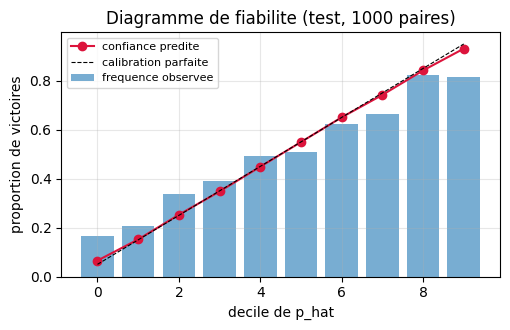

In [9]:
deciles = np.minimum((p_hat * 10).astype(int), 9)
rows = []
for k in range(10):
    m = deciles == k
    if m.sum() == 0:
        continue
    rows.append((k, m.sum(), float(np.mean(p_hat[m])), float(np.mean(y_test[m]))))

print(f"{'decile':>6}{'n':>6}{'confiance':>11}{'observe':>9}")
for k, n, conf, obs in rows:
    print(f"{k:>6}{n:>6}{conf:>11.3f}{obs:>9.3f}")

ece = sum(n * abs(conf - obs) for _, n, conf, obs in rows) / len(y_test)
conf_moy = float(np.mean(np.maximum(p_hat, 1 - p_hat)))
print(f"\nECE = {ece:.4f} | confiance moyenne {conf_moy:.3f} vs accuracy {acc:.3f} "
      f"(sur-confiance si confiance > accuracy)")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
c = [conf for _, n, conf, obs in rows]
o = [obs for _, n, conf, obs in rows]
ax.bar([i for i in range(len(rows))], o, width=0.8, alpha=0.6, label='frequence observee')
ax.plot(range(len(rows)), c, 'o-', color='crimson', label='confiance predite')
ax.plot([0, len(rows) - 1], [0.05, 0.95], 'k--', lw=0.8, label='calibration parfaite')
ax.set_xlabel('decile de p_hat'); ax.set_ylabel('proportion de victoires')
ax.set_title('Diagramme de fiabilite (test, 1000 paires)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lecture du diagramme.** Le motif est le classique **en éventail sur-confiant** :

- dans les déciles bas, la fréquence observée est *au-dessus* de la confiance (décile 0 :
  6.5 % annoncé, 16.7 % observé) — le modèle n'est pas assez sûr des paires qu'il perd ;
- dans les déciles hauts, elle est *en dessous* (décile 9 : 93.1 % annoncé, 81.6 % observé) —
  il est trop sûr des paires qu'il gagne.

D'où les chiffres agrégés : confiance moyenne **0.706** pour une accuracy de **0.653**
(+0.053 de sur-confiance) et un ECE de **0.053**. Mécanisme : la pousse BT
(section 6) récompense l'écart $\Delta \hat r$ tant que la paire est mal classée — rien ne
la stoppe au bon niveau, et les paires faciles deviennent des probabilités extrêmes. Le
plancher de Brier (0.0993) n'est atteignable qu'en reproduisant *les probabilités du juge*,
pas en gagnant toutes les paires.

C'est précisément ce défaut que l'exercice 1 attaque (pénalité sur $\hat r^2$), et c'est
pourquoi la pénalité KL de `rlpt_1` est indispensable en aval : un reward sur-étalonné
pousserait la politique trop fort.

## 9. Le score absolu récupère-t-il l'échelle vraie ?

Bradley-Terry n'entraîne que sur des **différences** : rien ne contraint la *position* ni la
*pente* de $\hat r$ par rapport à $r^*$. Pour le vérifier, on régresse $\hat r$ sur $r^*$ sur
les 2000 réponses de test : si le modèle a récupéré l'échelle, la relation est affine proche de
la diagonale ; la qualité de ce fit affine ($R^2$) mesure ce que le pooling + la tête scalaire
ont réellement appris de la structure du reward.

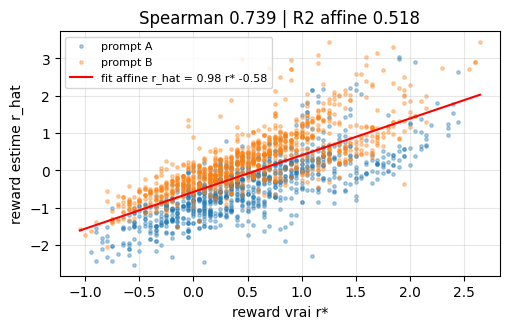

fit affine : r_hat ~= 0.983 * r* -0.582   (R2 = 0.518)
ecart-type de r_hat = 0.891 vs r* = 0.652


In [10]:
alpha_fit, beta_fit = np.polyfit(rs_test.flatten(), r_hat.flatten(), 1)
resid = r_hat.flatten() - (alpha_fit * rs_test.flatten() + beta_fit)
r2 = 1 - np.var(resid) / np.var(r_hat)

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for p_val, nom, coul in [(0, 'prompt A', 'tab:blue'), (1, 'prompt B', 'tab:orange')]:
    m = (pr_test == p_val)
    mm = np.repeat(m, 2)
    ax.scatter(rs_test.flatten()[mm], r_hat.flatten()[mm], s=6, alpha=0.35,
               color=coul, label=nom)
xs = np.linspace(rs_test.min(), rs_test.max(), 50)
ax.plot(xs, alpha_fit * xs + beta_fit, 'r-', lw=1.5,
        label=f'fit affine r_hat = {alpha_fit:.2f} r* {beta_fit:+.2f}')
ax.set_xlabel('reward vrai r*'); ax.set_ylabel('reward estime r_hat')
ax.set_title(f'Spearman {rho:.3f} | R2 affine {r2:.3f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"fit affine : r_hat ~= {alpha_fit:.3f} * r* {beta_fit:+.3f}   (R2 = {r2:.3f})")
print(f"ecart-type de r_hat = {np.std(r_hat):.3f} vs r* = {np.std(rs_test):.3f}")

**Lecture du nuage.** Le fit affine $\hat r \approx 0.983 \, r^* - 0.582$ décompose ce que
le modèle a appris :

- **la pente $\alpha = 0.983$** : l'échelle est récupérée quasi exactement — un point de
  score du reward vrai vaut ~un point de score estimé. Ce n'est pas automatique : BT ne
  contraint la pente qu'au travers des probabilités du juge effectivement observées ; la
  retrouver si précisément signale que les 4000 paires couvrent bien la plage de $\Delta r^*$.
- **l'interception $\beta_0 = -0.58$** : quelconque par construction (section 10) — la
  translation est le degré de liberté que la perte ne voit pas.
- **$R^2 = 0.518$** : la moitié de la variance de $\hat r$ est du bruit individuel. Les
  écarts-types le confirment : $\sigma_{\hat r} = 0.891$ pour $\sigma_{r^*} = 0.652$, soit
  un résidu $\approx 0.62$ — comparable au signal. Chaque réponse est notée avec une erreur
  du même ordre que l'écart-type du reward vrai ; c'est **suffisant pour classer des paires**
  (accuracy quasi au plafond) et **insuffisant pour trier finement des réponses proches**.

La couleur par prompt montre que le RM a bien appris le conditionnement : les deux nuages
sont alignés sur la même droite, sans décalage systématique entre prompt A et prompt B.

## 10. Identification : Bradley-Terry ne fixe que les différences

La théorie dit que $r^*$ et $r^* + c$ (translation constante) définissent **exactement** les
mêmes préférences — donc la même vraisemblance d'entraînement. Un reward model n'est identifiable
qu'**à translation près** (et, à gradient près, approximativement à échelle près sur les paires
réellement observées). C'est une propriété, pas un défaut : en RLHF, seule la *difference* de
reward entre deux réponses alimente la politique.

Vérification directe : décaler tous les scores du modèle d'une constante $c = 5.0$ et recalculer
les probabilités de chaque paire — elles doivent être inchangées à l'erreur flottante près. La
conséquence pratique : **exiger que $\hat r$ approxime $r^*$ en absolu n'a pas de sens
d'entraînement** ; ce notebook le mesure quand même (section 9) parce que le monde synthétique le
permet, et que la qualité du fit affine prouve que la *structure* du reward est apprise.

In [11]:
with torch.no_grad():
    r_shift = model(x_test.reshape(-1, 1 + LEN_R)).numpy().reshape(len(y_test), 2) + 5.0
p_shift = 1.0 / (1.0 + np.exp(-(r_shift[:, 0] - r_shift[:, 1])))
ecart = float(np.max(np.abs(p_shift - p_hat)))
print(f"decalage c = +5.0 sur tous les scores :")
print(f"  max |p_shift - p_hat| sur 1000 paires = {ecart:.2e}")
print(f"  accuracy inchangee : {float(np.mean((r_shift[:, 0] > r_shift[:, 1]) == (y_test == 1))):.3f} "
      f"(= {acc:.3f})")
print("\nla translation n'est pas observable par la perte BT : r_hat est identifiable a c pres")

decalage c = +5.0 sur tous les scores :
  max |p_shift - p_hat| sur 1000 paires = 1.79e-07
  accuracy inchangee : 0.653 (= 0.653)

la translation n'est pas observable par la perte BT : r_hat est identifiable a c pres


## 11. Multi-seed : la stabilité de la boucle

Un seul entraînement ne prouve rien (init, ordre des lots, tirage des paires). Convention de la
série (`rlpt_1`, review C) : quatre seeds `[0, 1, 7, 42]`, moyenne ± écart-type. Le monde, les
paires, le juge, l'initialisation et l'ordre des mini-lots sont re-tirés à chaque seed — la
dispersion mesure donc la variabilité **end-to-end** du pipeline complet.

In [12]:
def run_seed(seed, n_train=4000, n_test=1000):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    tr, ytr, rstr, ptr = make_pairs(n_train, rng)
    te, yte, rste, pte = make_pairs(n_test, rng)
    xtr, xte = encode(tr, ptr), encode(te, pte)
    d = rste[:, 0] - rste[:, 1]
    p_t = 1.0 / (1.0 + np.exp(-d))
    m = RewardModel()
    h = train_bt(m, xtr, ytr)
    r_h, p_h, a, b = predict_pairs(m, xte, yte)
    _, _, a_tr, _ = predict_pairs(m, xtr, ytr)
    sp, _ = spearmanr(r_h.flatten(), rste.flatten())
    return dict(seed=seed, acc=a, acc_tr=a_tr,
                bayes=float(np.mean(np.maximum(p_t, 1 - p_t))),
                brier=b, brier_bayes=float(np.mean(np.minimum(p_t**2, (1 - p_t)**2))),
                rho=float(sp), lossf=h[-1])


res = [run_seed(s) for s in SEEDS]
print(f"{'seed':>4} {'acc_tr':>7} {'acc':>6} {'bayes':>6} {'ecart':>7} {'brier':>7} {'planch':>7} "
      f"{'rho':>6} {'lossf':>6}")
for r in res:
    print(f"{r['seed']:>4} {r['acc_tr']:>7.3f} {r['acc']:>6.3f} {r['bayes']:>6.3f} "
          f"{r['acc'] - r['bayes']:>+7.3f} {r['brier']:>7.4f} {r['brier_bayes']:>7.4f} "
          f"{r['rho']:>6.3f} {r['lossf']:>6.3f}")

g = lambda k: np.mean([r[k] for r in res])
s = lambda k: np.std([r[k] for r in res])
print(f"\nmoyennes : acc {g('acc'):.3f} +- {s('acc'):.3f} (Bayes {g('bayes'):.3f}, "
      f"train {g('acc_tr'):.3f}) | Brier {g('brier'):.4f} (plancher {g('brier_bayes'):.4f}) "
      f"| rho {g('rho'):.3f} | perte {g('lossf'):.3f}")

seed  acc_tr    acc  bayes   ecart   brier  planch    rho  lossf
   0   0.712  0.653  0.697  -0.044  0.2194  0.0993  0.739  0.576
   1   0.692  0.669  0.695  -0.026  0.2226  0.1003  0.848  0.590
   7   0.708  0.648  0.693  -0.045  0.2242  0.1016  0.794  0.584
  42   0.677  0.661  0.694  -0.033  0.2170  0.1007  0.793  0.604

moyennes : acc 0.658 +- 0.008 (Bayes 0.695, train 0.697) | Brier 0.2208 (plancher 0.1005) | rho 0.793 | perte 0.589


**Lecture multi-seed.** Sur quatre seeds complètes (données, juge, init, ordre des lots
re-tirés) :

| Métrique | Moyenne ± écart-type | Lecture |
|---|---|---|
| accuracy test | **0.658 ± 0.008** | stable, toujours à ~0.04 du plafond (0.695) |
| accuracy train | 0.697 | = plafond de Bayes : le modèle sature son train sans exploser |
| Brier | 0.2208 ± 0.003 | écart au plancher (0.1005) systématique — le défaut de calibration est structurel, pas une seed malheureuse |
| Spearman | 0.793 ± 0.04 | la dispersion vient surtout de la qualité du fit individuel |
| perte finale | 0.589 | contre log 2 = 0.693 : apprentissage net mais borné par l'entropie du juge |

Aucune seed ne s'égare (pire écart au plafond : −0.045) ; la boucle est **robuste**. Le
défaut récurrent — Brier 2.2x son plancher — est le même sur toutes les seeds : ce n'est pas
de la variance, c'est la sur-confiance structurelle de la perte BT, à traiter par
régularisation (exercice 1) ou par la pénalité KL en aval (`rlpt_1`).

## 12. Ce qu'il faut retenir

| Leçon | Mesure dans ce notebook |
|---|---|
| Comparer suffit à noter | un RM de 9k paramètres reconstruit $\rho \approx 0.8$ avec $r^*$ |
| Le plafond n'est pas 100 % | acc 0.658 ± 0.008 vs plafond de Bayes 0.695 : l'écart au plafond est la vraie métrique |
| Le juge est bruit — le RM hérite du bruit | Brier 0.221 vs plancher 0.100 : l'écart restant est le résidu de calibration, pas de la capacité |
| BT n'identifie que les différences | translation $c$ : probabilités inchangées ; le fit affine (§9) mesure la structure apprise |
| Le piège est dans les indices | win = `x[range(B), 1-y]` — une inversion converge quand même, vers l'anti-reward |

**Ce que ce notebook ajoute à la série** : `rlpt_1` code son reward en dur ; `rlpt_2` invoque un
reward vérifiable ; ici le reward est **appris de données de préférence** — le chaînon qui, dans
le pipeline réel, s'appelle `trl.RewardTrainer` et précède toute optimisation. Les limites vues
ici annoncent la suite :

- l'optimisation contre un reward *approché* peut dériver vers ses failles — **reward hacking**
  (`rlpt_3`) ;
- et si l'on pousse la logique « la politique n'a besoin que des préférences » jusqu'au bout, on
  peut **supprimer le reward model** de la boucle — **DPO** (`rlpt_4`).

## Exercices

Trois exercices, du plus guidé au plus ouvert. Ils étendent directement les fonctions définies
ci-dessus (`make_pairs`, `train_bt`, `predict_pairs`) — aucune nouvelle dépendance.

### Exercice 1 : régulariser le score pour calibrer

La section 8 a mesuré un écart de calibration (Brier ~2x son plancher). Une cause classique : la
pousse BT amplifie les écarts $\hat r(y_w) - \hat r(y_l)$ sur les paires faciles, rendant
$\hat p$ trop extrême. On peut contenir le score absolu par une pénalité
$\lambda \, \mathbb{E}[\hat r^2]$ ajoutée à la perte.

1. Écrire `train_bt_reg(model, x, y, lam)` : copie de `train_bt` avec le terme de pénalité sur
   les scores **des deux bras** du lot (attention : `model(win)` et `model(lose)` sont déjà
   calculés — les réutiliser, ne pas doubler le forward).
2. Entraîner avec `lam = 0.01` et `lam = 0.1` (seeds 0), comparer Brier, ECE et accuracy au
   modèle non régularisé.
3. À quel `lam` la calibration s'améliore-t-elle **sans** dégrader l'accuracy ? Interpréter le
   compromis en termes de translation/échelle (section 10).

*Indice : la pénalité n'agit que sur la partie « position/échelle » du score — invisible pour la
perte BT — donc elle peut resserrer $\hat p$ sans toucher au classement.*

In [13]:
# TODO etudiant : train_bt_reg avec penalite lam * mean(r_win^2 + r_lose^2)
# Etape 1 : copier train_bt, ajouter le terme de penalite dans `loss`
# Etape 2 : boucle sur lam dans [0.0, 0.01, 0.1] avec torch.manual_seed(0)
# Etape 3 : pour chaque lam, afficher Brier + ECE + accuracy sur le test
#           (reutiliser predict_pairs et le calcul ECE de la section 8)
resultats_reg = None   # TODO etudiant : liste de dicts {lam, brier, ece, acc}
print("Exercice a completer")

Exercice a completer


### Exercice 2 : un juge plus bruité (beta)

Le paramètre $\beta$ du juge (section 3) règle sa *netteté* : $\beta = 1$ ici,
$\beta = 0.5$ = juge indécis, $\beta = 2$ = juge tranchant. La théorie BT dit que le RM entraîné
sur un juge $\beta$ apprend une échelle $\beta$-dilatée de $r^*$.

1. Régénérer paires train/test avec `make_pairs(..., beta=0.5)` (le reste inchangé).
2. Recalculer le plafond de Bayes **du nouveau juge** (attention : c'est $\sigma(0.5\,\Delta r^*)$
   qu'il faut utiliser, pas $\sigma(\Delta r^*)$).
3. Réentraîner le RM et vérifier : (a) l'accuracy tombe-t-elle vers le nouveau plafond ?
   (b) le fit affine $\hat r \approx \alpha r^* + \beta_0$ donne-t-il $\alpha \approx 0.5$ ?

*Indice : pour (b), la fonction `np.polyfit` de la section 9 fait l'affaire ; comparer aussi la
perte NLL finale à l'entropie du nouveau juge.*

In [14]:
# TODO etudiant : juge beta = 0.5
# Etape 1 : rng2 = np.random.default_rng(0) ; regenerer train/test avec beta=0.5
# Etape 2 : plafond de Bayes du juge beta=0.5 : sigma(0.5 * Delta r*)
# Etape 3 : reentrainer (torch.manual_seed(0), train_bt) et mesurer
#           acc vs plafond, alpha du fit affine, NLL vs entropie du juge
resultats_beta = None   # TODO etudiant : dict {acc, bayes, alpha, nll}
print("Exercice a completer")

Exercice a completer


### Exercice 3 : budget d'étiquettes — paires aléatoires vs paires serrées

Chaque paire étiquetée coûte (temps d'annotateur). À budget fixe, quelles paires collecter ?
Hypothèse : les paires **serrées** ($|\Delta r^*|$ petit) portent plus d'information pour
apprendre l'échelle fine ; les paires larges sont « faciles » et leur gradient s'annule vite
(section 6).

1. Générer un réservoir de 8000 paires candidates (seed 0). Trier par $|\Delta r^*|$ croissant.
2. Armée A : prendre 1500 paires **au hasard** ; armée B : prendre les 1500 **plus serrées**
   (au-dessus du filtre `min_gap = 0.3` déjà appliqué). Même budget d'étiquettes.
3. Entraîner deux RM (seed 0) et comparer accuracy held-out et Spearman $\rho$ sur le **même**
   test.

Le verdict est-il net ? Discuter : que prédit la théorie de l'information sur l'emplacement de
l'information manquante, et pourquoi le monde réel (annotateurs humains) complique-t-il ce plan ?

*Indice : pour trier, `np.argsort(np.abs(d))` ; les labels restent ceux du juge BT — on ne
change que la politique de sélection des paires.*

In [15]:
# TODO etudiant : paires aleatoires vs paires serrees a budget egal (1500)
# Etape 1 : reservoir de 8000 paires (seed 0), tri par |Delta r*| croissant
# Etape 2 : armee A = 1500 au hasard ; armee B = 1500 plus serrees
# Etape 3 : deux train_bt (seed 0), comparer acc et rho sur le test commun
resultats_budget = None   # TODO etudiant : dict {acc_A, rho_A, acc_B, rho_B}
print("Exercice a completer")

Exercice a completer
